In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from belief_dynamics_learning.world2d import World2D
from belief_dynamics_learning.dpf import *
from belief_dynamics_learning.dpf_utils import *

%load_ext autoreload
%autoreload 2

Example demonstration of 2D world, belief of the object pose, and robot trajectory in the 2D world.

In [2]:
num_particles = 100
dt = 0.1

# object properties 
dim_object = np.array([0.067, 0.14])
qo_gt = np.array([0, 1, 0]) # ground truth object pose
sigma_pos = 0.06 # standard deviation of position noise

# robot properties
qr_0 = np.array([0, 0.7])
r_robot = 0.05


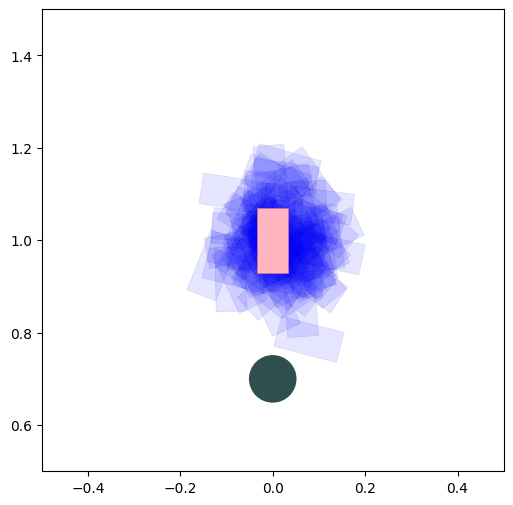

In [3]:
world = World2D(num_particles, qo_gt, dim_object, sigma_pos, 
                qr_0, r_robot, dt)
world.plot_belief()

Keeping indices: [25, 45]


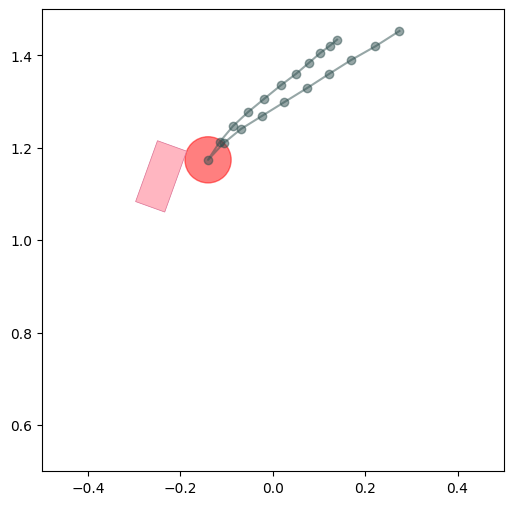

In [4]:
world.sample_gt_object_pose()
world.sample_robot_pose()
q_r_hist, o_hist, a_hist = world.rollout(100, world.qo_gt.copy())

# only keep bits of sequence around positive contact measurements

contact_idx = np.where(o_hist==1)[0]
if len(contact_idx) == 0:
    print('No contact detected')
else:
    min_idx = np.min(contact_idx)
    max_idx = np.max(contact_idx)
    buffer_lb = np.min([min_idx, 10])
    buffer_ub = np.min([len(o_hist)-max_idx, 10])
    keep_idx = [min_idx-buffer_lb, max_idx+buffer_ub]
    print('Keeping indices:', keep_idx)
    q_r_hist = q_r_hist[keep_idx[0]:keep_idx[1]]
    o_hist = o_hist[keep_idx[0]:keep_idx[1]]
    world.plot_rollout(q_r_hist, o_hist)

Differentiable particle filter

In [5]:
# initialise hyperparameters for the differentiable particle filter (DPF)
propose_ratio = 0.7
# proposer_keep_ratio = 0.3
proposer_keep_ratio = 0.15 # what it was set to initially and from the paper code
min_obs_likelihood = 0.004

# initialise hyperparameters for the DPF training
split_ratio = 0.8
seq_len = 3
batch_size = 20
num_epochs = 100
num_epochs_ole = 300
patience = 10
# learning_rate = 0.01
learning_rate = 0.0003
dropout_keep_ratio = 0.3
num_particles = 100
particle_std = 0.2
contact_only = True
xy_only = False
phi_dataset = True

# create instance of DPF class
dpf = DPF(propose_ratio, proposer_keep_ratio, min_obs_likelihood, num_particles, world, xy_only, phi_dataset)

In [6]:
# find file path to the training data
root = os.getcwd()
save_path = os.path.join(root, '../data/phi_data_min_3_contacts_seq_len_3_test_100_trajectories.pkl')

# ensure the training data file exists before attempting to load it
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        raw_data = pickle.load(f)
else:
    print("File not found:", save_path)

Organise data into a dictionary

Object pose data: (500, 1, 3)
Robot pose data: (500, 1, 2)
Observation data: (500, 1, 1)
Action data: (500, 1, 2)
Object pose (example trajectory): [-0.02224816  1.11093663  2.73447661]
Robot pose (example trajectory): [[-0.07351007  1.20293493]]
Observation (example trajectory): [[1.]]
Action (example trajectory): [[-0.06196252  1.19795555]]


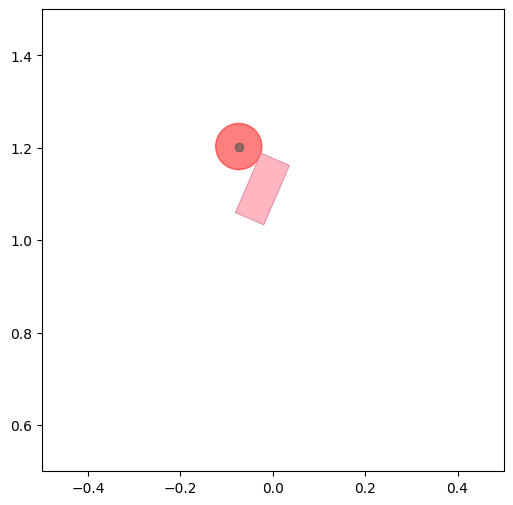

In [7]:
# data generation parameters
num_sequences = 100
num_steps_per_sequence = seq_len

data = organise_data_phi(raw_data, num_sequences, num_steps_per_sequence, contact_only, xy_only)
    
# verify shapes of matrices containing 
print('Object pose data:', data['q_o'].shape)
print('Robot pose data:', data['q_r'].shape)
print('q_o_r data:', data['q_o_r'].shape)
print('Phi observation data:', data['phi'].shape)
print('Closest point data:', data['cp'].shape)
# print('Action data:', data['a'].shape) # note: action was modified so it represents current desired robot position

# plot example trajectory from the dataset
traj = np.random.randint(0, num_sequences)
print('Object pose (example trajectory):', data['q_o'][traj, :, :])
print('Robot pose (example trajectory):', data['q_r'][traj, 0, :])
print('q_o_r data (example trajectory):', data['q_o_r'][traj, 0, :])
print('Phi observation (example trajectory):', data['phi'][traj, 0, :])
print('Closest point (example trajectory):', data['cp'][traj, 0, :])
# print('Action (example trajectory):', data['a'][traj, 0, :])
world.qo_gt = data['q_o'][traj, 0, :]
world.plot_rollout(data['q_r'][traj, :, :], 1)
# world.plot_rollout(data['q_r'][traj, :, :], data['o'][traj, :, :])

In [ ]:
# noisify data
data = noisify_data(data)

In [8]:
# # checking for errors in the dataset
# data_errors_only = check_errors_data(data, dpf.world.obj_dims, dpf.world.r_robot, xy_only)

# num_errors_in_data = data_errors_only['q_o'].shape[0]
# print('Number of errors (intersections) in data:',num_errors_in_data)
# traj = np.random.randint(0, num_errors_in_data)
# print('Object pose (example trajectory):', data_errors_only['q_o'][traj, 0, :])
# print('Robot pose (example trajectory):', data_errors_only['q_r'][traj, :, :])
# print('Observation (example trajectory):', data_errors_only['o'][traj, :, :])
# print('Action (example trajectory):', data_errors_only['a'][traj, :, :])

# q_r = torch.from_numpy(data['q_r'][traj:traj+1, :, :]) # [1, 1, 2]
# q_o = torch.from_numpy(data['q_o'][traj:traj+1, :, None, :]) # [1, 1, 1, state_dim]
# d = dist_to_object_torch(q_r, q_o, dpf.world.obj_dims, dpf.world.r_robot, xy_only)
# print('Distance:', d)

# world.qo_gt = data_errors_only['q_o'][traj, 0, :]
# world.plot_rollout(data_errors_only['q_r'][traj, :, :], data_errors_only['o'][traj, :, :])

In [9]:
# compute some statistics aboout the data
means, stds, q_o_r_maxs, q_o_r_mins, q_r_step_sizes, q_r_maxs, q_r_mins = compute_statistics(data, phi_dataset)
print(q_o_r_mins)

[-0.39592122  0.60293977 -3.12661129]


/opt/anaconda3/envs/summer-proj/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/summer-proj/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
# train_data, val_data = split_data(data, split_ratio)

# print('Training data:', train_data['q_r'].shape)
# print('Validation data', val_data['q_r'].shape)

In [11]:
# # create dataset and dataloader for training and validation
# train_dataset = TrajectoriesDataset(train_data, seq_len)
# val_dataset = TrajectoriesDataset(val_data, seq_len)

# train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

# # test the dataloader
# for batch in train_dataloader:
#     print(batch['q_o'].shape)  # Expected shape: [20, 1, 3]
#     print(batch['q_r'].shape)  # Expected shape: [20, 100, 2]
#     print(batch['q_o_r'].shape) # Expected shape: [20, 100, 1]
#     print(batch['phi'].shape)    # Expected shape: [20, 100, 2]
#     break

In [12]:
# # check that models have been built
# dpf.build_networks()
# print(dpf.obs_like_estimator)
# print(dpf.particle_proposer)

In [13]:
# iterator = iter(train_dataloader)
# batch = next(iterator)

# a_batch = batch['a'][:, 0, :]
# q_r_batch = batch['q_r'][:, 0, :]
# o_batch = batch['o'][:, 0, :]
                    
# # define input to the particle proposer network
# input_pp = torch.cat((a_batch, q_r_batch, o_batch), -1)

# print(input_pp.shape)

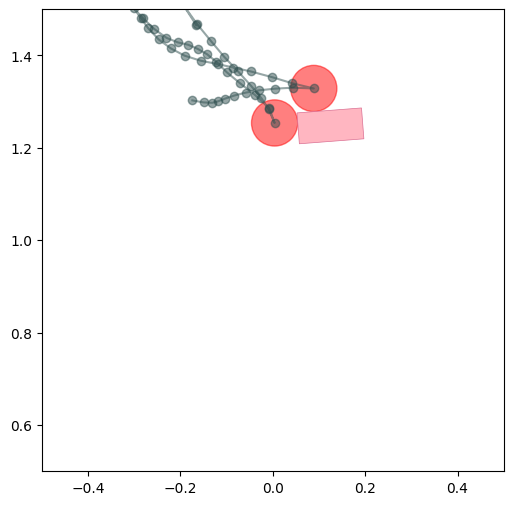

Desired robot position during contact event: tensor([[0.0891, 1.3260]], dtype=torch.float64)
Achieved robot position during contact event: tensor([[0.0889, 1.3286]], dtype=torch.float64)
Observation during contact event: tensor([[1]])


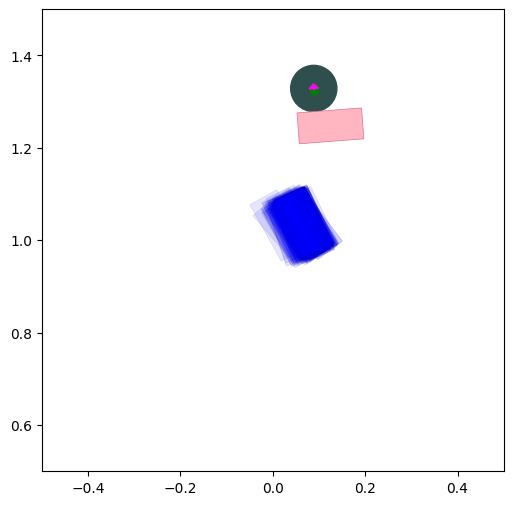

In [14]:
dpf.test(q_o_r_mins, q_o_r_maxs, means, stds, xy_only)

Epoch 1/100
torch.Size([20, 100, 3])
particle_list tensor([[0.0690, 1.0292, 0.5002],
        [0.0713, 1.0312, 0.5081],
        [0.0387, 1.0076, 0.6378],
        [0.0681, 1.0227, 0.5000],
        [0.0673, 1.0244, 0.4207],
        [0.0744, 1.0279, 0.5543],
        [0.0518, 1.0269, 0.4382],
        [0.0713, 1.0312, 0.5081],
        [0.0803, 1.0359, 0.5287],
        [0.0573, 1.0265, 0.5605]], dtype=torch.float64,
       grad_fn=<SliceBackward0>)
batch_q_o: tensor([ 0.2939,  1.1090, -0.2164], dtype=torch.float64)
sq_distance: tensor([6.2086, 6.0860, 8.2705, 6.3576, 6.2560, 6.0686, 6.9641, 6.0860, 5.6521,
        6.8850], dtype=torch.float64, grad_fn=<SliceBackward0>)
activations: tensor([3.9372e-36, 1.8230e-35, 2.5226e-47, 6.1143e-37, 2.1782e-36, 2.2658e-35,
        3.1170e-40, 1.8230e-35, 4.1326e-33, 8.3819e-40], dtype=torch.float64,
       grad_fn=<SliceBackward0>)
sum of activations: tensor([[ 2.6462e-32],
        [ 5.1312e-39],
        [8.7218e-108],
        [ 7.8230e-68],
        [4.05

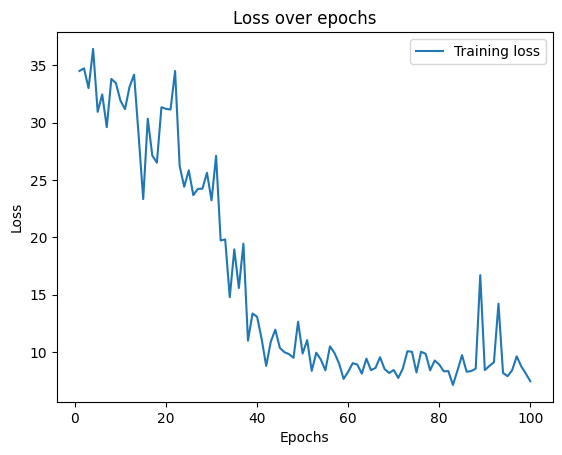

In [15]:
# if contact_only == True:
#     seq_len = 1

# train the dpf and extract the last batch from training
# q_o, particle_list, particle_prob_list = dpf.fit(data, split_ratio, batch_size, seq_len, num_epochs, patience, learning_rate, num_particles, xy_only, phi_dataset) # form GMM plots
dpf.fit(data, split_ratio, batch_size, seq_len, num_epochs, num_epochs_ole, learning_rate, num_particles, xy_only, phi_dataset)

x
max and min: 1.0643839563702562 2.777692937735484e-193
y
max and min: 0.438737455319636 7.489486207029756e-77
theta
max and min: 0.38702127850855084 0.014133723480948192


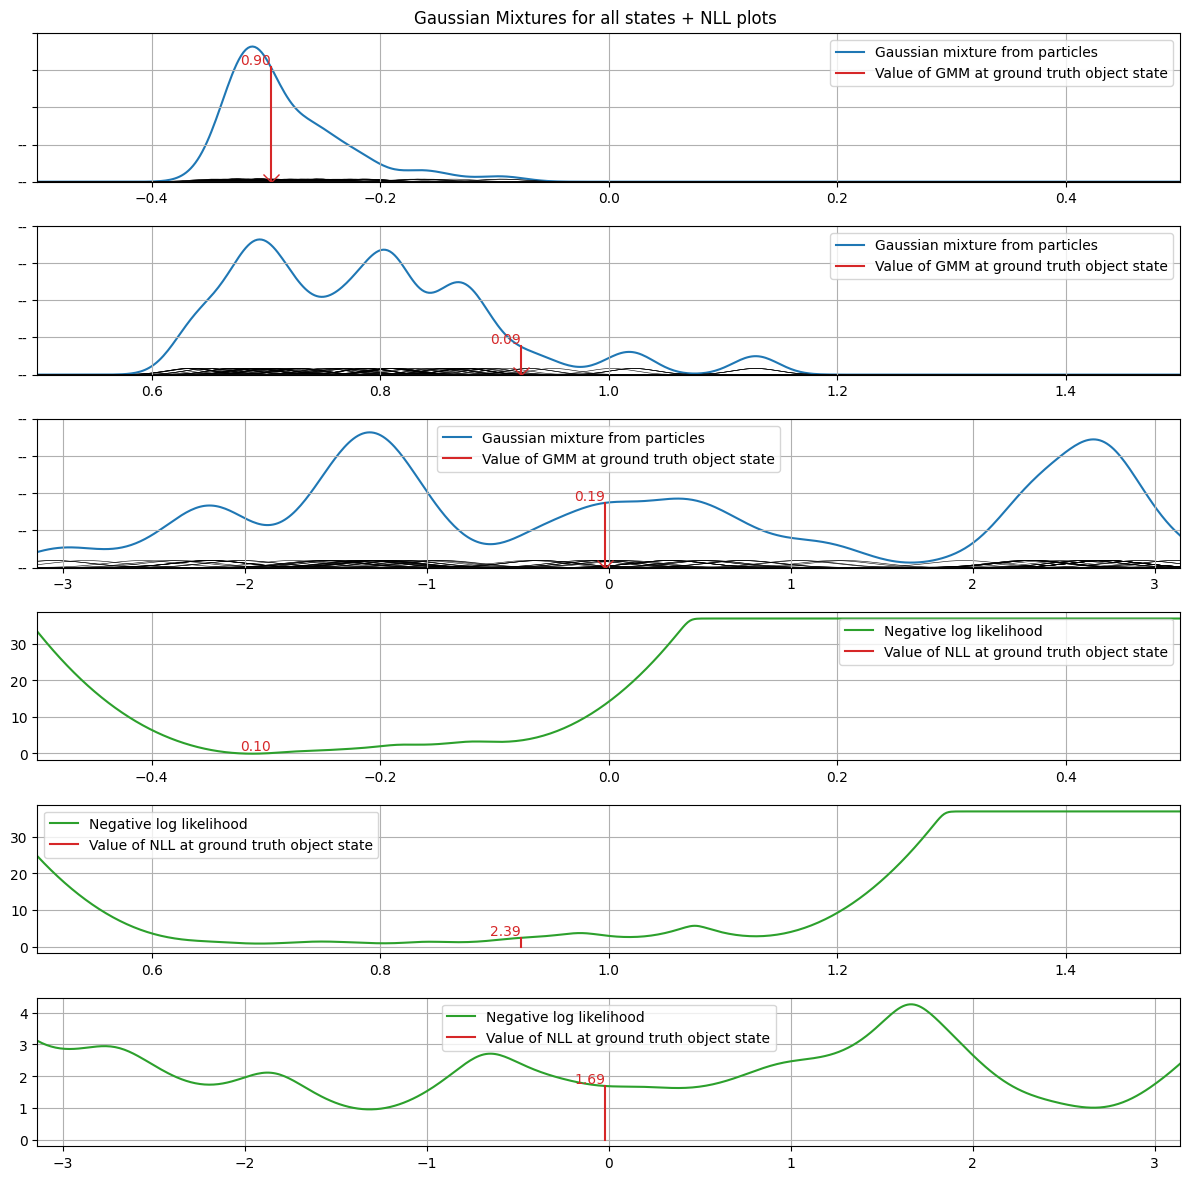

In [16]:
# # plot GMM
# dpf.plot_GMM(q_o, particle_list, particle_prob_list, xy_only)

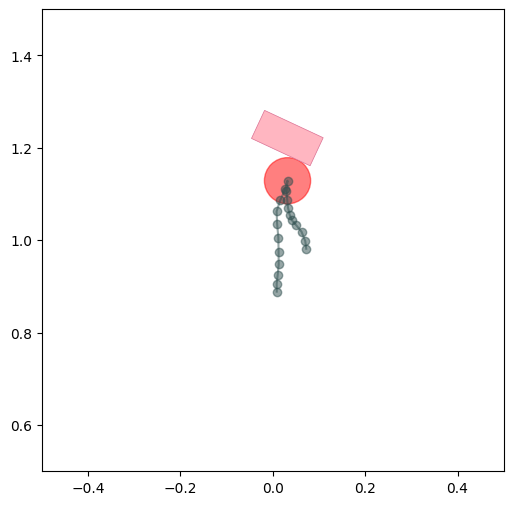

Desired robot position during contact event: tensor([[0.0349, 1.1351]], dtype=torch.float64)
Achieved robot position during contact event: tensor([[0.0320, 1.1289]], dtype=torch.float64)
Observation during contact event: tensor([[1]])


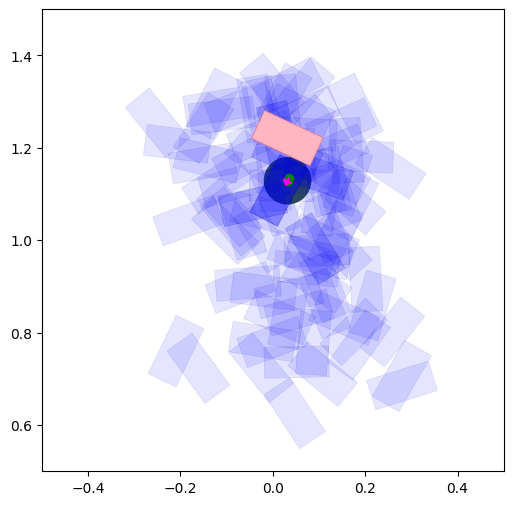

In [17]:
dpf.test(q_o_r_mins, q_o_r_maxs, means, stds, xy_only)

Plotting particles, their sq_distance, and activations:

In [18]:
# particles_with_theta = np.array([[ 0.2491,  1.2681,  0.7917, -0.8646],
#         [ 0.2978,  1.3311, -0.9801, -0.2196],
#         [ 0.2807,  1.3677, -0.6394, -0.7929],
#         [ 0.0838,  1.3630,  0.9265,  0.0844],
#         [ 0.2840,  1.3112, -0.9944,  0.0935],
#         [ 0.3322,  1.3557, -0.9607, -0.8444],
#         [ 0.2978,  1.3311, -0.9801, -0.2196],
#         [ 0.3067,  1.3161, -0.8168, -0.8680],
#         [ 0.2932,  1.3407, -0.8729,  0.6077],
#         [ 0.3126,  1.2822, -0.6303, -0.9263]])

# x_position = particles_with_theta[:,0]
# y_position = particles_with_theta[:,1]

# gt_object_pose = np.array([0.2310, 1.2268, 0.6781])
# x_object = gt_object_pose[0]
# y_object = gt_object_pose[1]

# plt.plot(x_position, y_position, 'o')
# plt.plot(x_object, y_object, 'o')

# sq_distance = [0.0911, 0.1678, 0.1835, 0.0529, 0.1471, 0.2345, 0.1678, 0.2050, 0.1260, 0.1857]
# activations = [1.7428e-12, 6.7830e-23, 5.0403e-25, 2.6637e-07, 4.3674e-20, 5.9427e-32, 6.7830e-23, 6.0809e-28, 3.1849e-17, 2.5056e-25]

# plt.plot(x_position, y_position, 'o', label='Particles')
# plt.plot(x_object, y_object, 'o', label='Ground Truth Object Pose')

# # Annotate each particle with its squared distance and activation
# for i, (x, y, dist, act) in enumerate(zip(x_position, y_position, sq_distance, activations)):
#     plt.text(x, y, f'{dist:.2f}', fontsize=7, ha='right', va='bottom')
#     plt.text(x, y, f'{act:.2e}', fontsize=7, ha='right', va='top', color='blue')

# plt.xlabel('X Position')
# plt.ylabel('Y Position')
# plt.legend()
# plt.axis('equal')
# plt.xlim([-0.5, 0.5])
# plt.ylim([0.5, 1.5])
# plt.show()

Double checking dist_to_object_torch() --> seems correct

In [19]:
# def dist_to_object_torch(q_r, particle_list, dim_object, r_robot, xy_only):
#     """
#     Using PyTorch, compute the shortest distance between the robot and the object
#     Args:
#         q_r: [batch_size, seq_len, 2]
#         particle_list: [batch_size, seq_len, num_particles, state_dim]
#     Returns:   
#         d: shortest distance (tensor)
#     """
#     if xy_only == True:
#         zero_angles = torch.zeros(particle_list.shape[0], particle_list.shape[1], particle_list.shape[2], 1)
#         particle_list = torch.cat((particle_list, zero_angles), dim=-1)

#     q_r = q_r[:, :, None, :] # [batch_size, seq_len, 1, 2]
#     print('q_r:', q_r)
#     q_r_o = q_r - particle_list[:, :, :, :2] # [batch_size, seq_len, num_particles, 2]
#     print('q_r_o:', q_r_o)

#     theta = particle_list[:, :, :, 2] # [batch_size, seq_len, num_particles]
#     print('theta:', theta)
#     cos_theta = torch.cos(theta) # [batch_size, seq_len, num_particles]
#     print('cos:', cos_theta)
#     sin_theta = torch.sin(theta) # [batch_size, seq_len, num_particles]
#     print('sin:', sin_theta)
#     R = torch.stack((torch.stack((cos_theta, sin_theta), dim=-1), torch.stack((-sin_theta, cos_theta), dim=-1)), dim=-1) # [batch_size, seq_len, num_particle, 2, 2]
#     print('rotation matrix R:', R)

#     # first, add an extra dimension to q_r_o to make it compatible for matrix multiplication
#     q_r_o_expanded = q_r_o.unsqueeze(-1)  # [batch_size, seq_len, num_particles, 2, 1]
#     print('q_r_o_expanded:', q_r_o_expanded)
#     # perform the matrix multiplication
#     q_r_o = torch.matmul(R, q_r_o_expanded)  # [batch_size, seq_len, num_particles, 2, 1]
#     print('after matrix multiplication:', q_r_o)
#     # remove the last dimension to get back to shape [batch_size, seq_len, num_particles, 2]
#     q_r_o = q_r_o.squeeze(-1)
#     print('q_r_o:', q_r_o)

#     q_r_o_clipped = torch.clamp(q_r_o, torch.from_numpy(-dim_object/2), torch.from_numpy(dim_object/2))
#     print('q_r_o_clipped:', q_r_o_clipped)
#     d = torch.linalg.norm(q_r_o - q_r_o_clipped, ord=2, dim=-1) - r_robot # [batch_size, seq_len, num_particles]
#     print('distance:', d)

#     return d

# # place object a origin
# q_o = torch.zeros(1, 1, 1, 3)

# # place robot at some coordinate
# q_r = torch.tensor([1.0, 1.0])
# q_r = q_r.view(1, 1, 2)

# # other parameters
# dim_object = np.array([0.067, 0.14])
# r_robot = 0.05
# xy_only = False

# d = dist_to_object_torch(q_r, q_o, dim_object, r_robot, xy_only)